<a href="https://colab.research.google.com/github/riccardo03/Quant_preparation/blob/main/GARCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.2 MB/s eta 0:00:00


#BTC-USD analysis 2024-2025

In [ ]:
import yfinance as yf
import numpy as np
data = yf.download("BTC-USD", start="2024-01-01", end="2026-01-01", auto_adjust=True)
returns = 100 * np.log(data['Close'] / data['Close'].shift(1)).dropna()


print(returns.describe())
print(f"Skewness: {returns.skew().values[0]:.3f}")
print(f"Kurtosis: {returns.kurt().values[0]:.3f}")

[*********************100%***********************]  1 of 1 completed

Ticker     BTC-USD
count   730.000000
mean      0.093665
std       2.502612
min      -9.082270
25%      -1.210608
50%       0.034222
75%       1.294364
max      11.461586
Skewness: 0.263
Kurtosis: 2.201


#Plot
I plot the log-returns, the ACF of log-returns and the ACF of the squarred log-returns.
1. The ACF of log-returns tell me whether it's worth to use an ARIMA model.
2. The ACF of squared log-returns tell me whether it's worth to use GARCH to capture hidden relationships

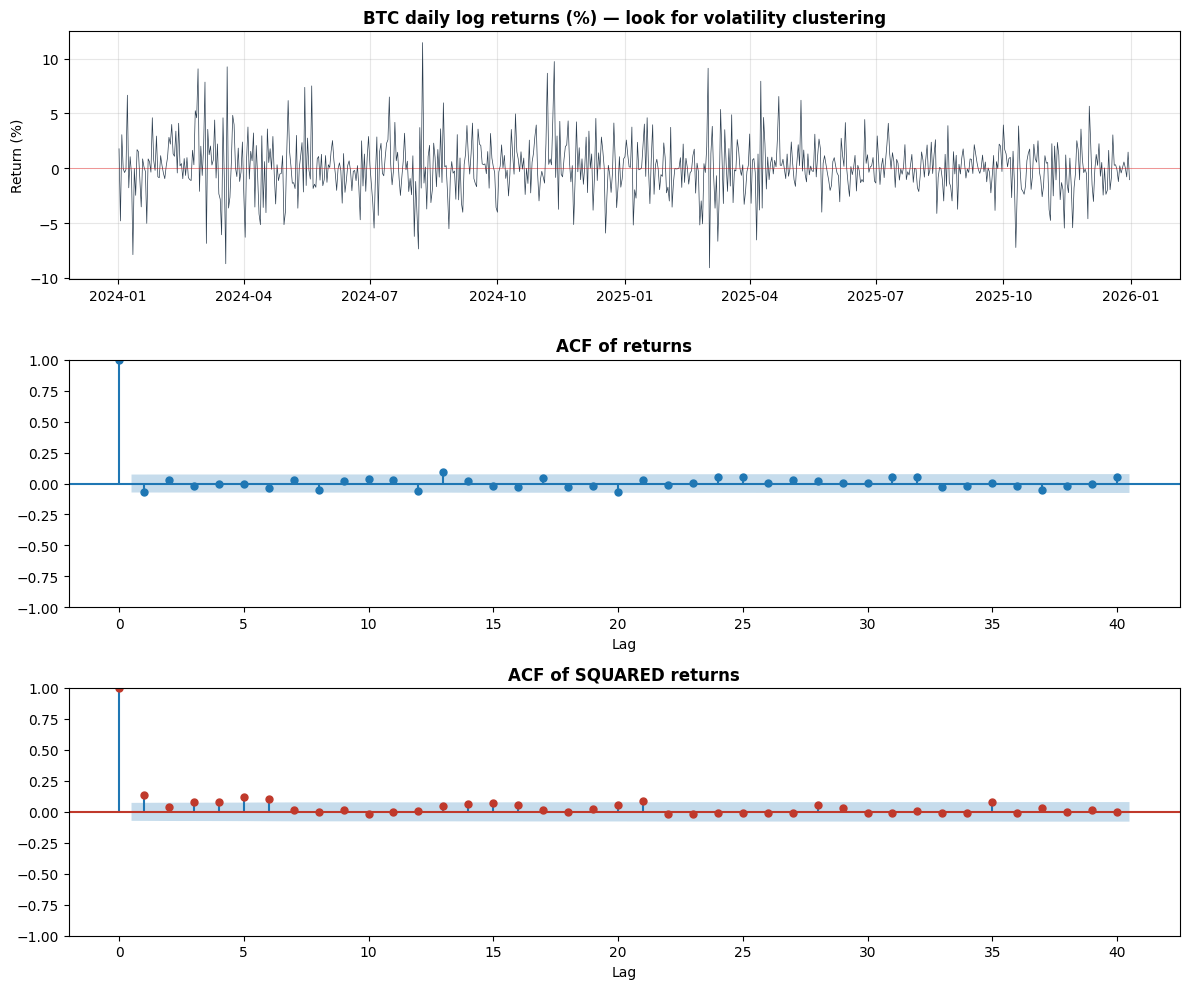


--- ACF at selected lags ---
 Lag      returns     sq.returns
   1      -0.0658         0.1337
   2       0.0307         0.0373
   5      -0.0021         0.1173
  10       0.0371        -0.0164
  20      -0.0658         0.0515

Engle's ARCH-LM test (lags=10):
  LM statistic: 33.46
  p-value:      2.28e-04


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import het_arch

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(returns.index, returns.values, linewidth=0.5, color="#2C3E50")
axes[0].axhline(0, color="red", linewidth=0.5, alpha=0.5)
axes[0].set_title("BTC daily log returns (%) — look for volatility clustering",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Return (%)")
axes[0].grid(alpha=0.3)

plot_acf(returns, lags=40, ax=axes[1], alpha=0.05)
axes[1].set_title("ACF of returns",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Lag")

plot_acf(returns**2, lags=40, ax=axes[2], alpha=0.05, color="#C0392B")
axes[2].set_title("ACF of SQUARED returns",
                  fontsize=12, fontweight="bold")
axes[2].set_xlabel("Lag")

plt.tight_layout()
plt.show()

# --- Numeric summary ---
acf_ret = acf(returns, nlags=20, fft=True)
acf_sq  = acf(returns**2, nlags=20, fft=True)

print("\n--- ACF at selected lags ---")
print(f"{'Lag':>4} {'returns':>12} {'sq.returns':>14}")
for lag in [1, 2, 5, 10, 20]:
    print(f"{lag:>4} {acf_ret[lag]:>12.4f} {acf_sq[lag]:>14.4f}")

# --- Engle's ARCH-LM test ---
lm_stat, lm_p, _, _ = het_arch(returns - returns.mean(), nlags=10)
print(f"\nEngle's ARCH-LM test (lags=10):")
print(f"  LM statistic: {lm_stat:.2f}")
print(f"  p-value:      {lm_p:.2e}")

In [ ]:
from arch import arch_model
model = arch_model(returns, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
res = model.fit(disp="off")
print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                BTC-USD   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1680.79
Distribution:                  Normal   AIC:                           3369.59
Method:            Maximum Likelihood   BIC:                           3387.96
                                        No. Observations:                  730
Date:                Tue, Apr 21 2026   Df Residuals:                      729
Time:                        15:58:03   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0951  8.397e-02      1.133      0.257 [-6.94

The model seems pretty robust. alpha and beta are significant.
t is the "t-statistic". It's simply the coefficients / std err: it's the number of std errs the estimate is away from zero.

Now that I have the baseline I can fit these other models, in particular the t-student.

In [18]:
from arch import arch_model
import pandas as pd

returns_recent = returns.loc["2023-01-01":]

models = {
    "GARCH-Normal":  arch_model(returns_recent, mean="Constant",
                                vol="GARCH", p=1, q=1, dist="normal"),
    "GARCH-t":       arch_model(returns_recent, mean="Constant",
                                vol="GARCH", p=1, q=1, dist="t"),
    "GJR-GARCH-t":   arch_model(returns_recent, mean="Constant",
                                vol="GARCH", p=1, o=1, q=1, dist="t"),
    "EGARCH-t":      arch_model(returns_recent, mean="Constant",
                                vol="EGARCH", p=1, o=1, q=1, dist="t"),
}

results = {name: m.fit(disp="off") for name, m in models.items()}

# --- Full summaries ---
for name, res in results.items():
    print(f"\n{'='*70}")
    print(f"  {name}")
    print('='*70)
    print(res.summary())

# --- Comparison table ---
comparison = pd.DataFrame({
    name: {
        "LogLik":  res.loglikelihood,
        "AIC":     res.aic,
        "BIC":     res.bic,
        "n_params": res.num_params,
    }
    for name, res in results.items()
}).T

print("\n" + "="*70)
print("  MODEL COMPARISON")
print("="*70)
print(comparison.round(2))

# Best by each criterion
print(f"\nBest by AIC: {comparison['AIC'].idxmin()}")
print(f"Best by BIC: {comparison['BIC'].idxmin()}")
print(f"Best by LogLik: {comparison['LogLik'].idxmax()}")


  GARCH-Normal
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                BTC-USD   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1680.79
Distribution:                  Normal   AIC:                           3369.59
Method:            Maximum Likelihood   BIC:                           3387.96
                                        No. Observations:                  730
Date:                Tue, Apr 21 2026   Df Residuals:                      729
Time:                        16:19:34   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0951  8.397e-02      1.133  

# FINAL MODEL


In [19]:
# Your final model for Steps 6 and 7:
model = arch_model(returns_recent, mean="Constant",
                   vol="GARCH", p=1, q=1, dist="t")
res = model.fit(disp="off")

Standardized residuals: n = 730
Mean:      0.0075  (should be ~0)
Std:       0.9603   (should be ~1)
Skew:      0.1962
Kurtosis:  1.6668  (excess)

  LJUNG-BOX TESTS

On standardized residuals (z_t):
    lb_stat  lb_pvalue
5    1.4544     0.9183
10   4.6171     0.9152
20  18.4907     0.5551
→ p-values should be > 0.05 (no autocorrelation left in mean)

On squared standardized residuals (z_t^2):
    lb_stat  lb_pvalue
5    5.5499     0.3525
10  11.8002     0.2987
20  14.0910     0.8259
→ p-values should be > 0.05 (no ARCH effects left — THE KEY TEST)

--- ACF at selected lags (should all be near zero) ---
 Lag          z_t        z_t^2
   1      -0.0144       0.0485
   2       0.0396      -0.0134
   5       0.0012       0.0679
  10       0.0358      -0.0424
  20      -0.0411       0.0003

95% CI for white noise: ±0.0725


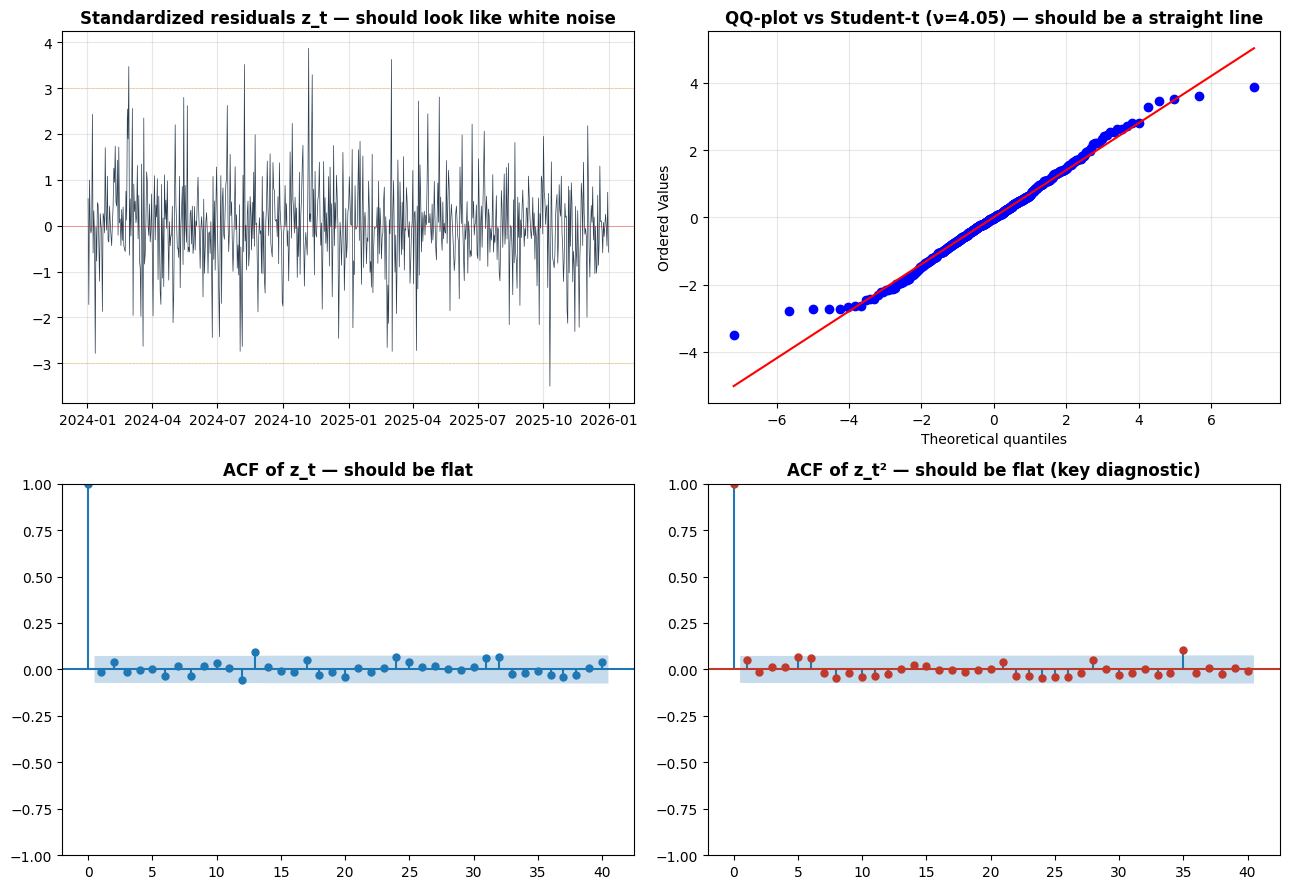

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf
from scipy import stats

# --- Compute standardized residuals ---
# z_t = eps_t / sigma_t
std_resid = res.std_resid.dropna()

print(f"Standardized residuals: n = {len(std_resid)}")
print(f"Mean:      {std_resid.mean():.4f}  (should be ~0)")
print(f"Std:       {std_resid.std():.4f}   (should be ~1)")
print(f"Skew:      {std_resid.skew():.4f}")
print(f"Kurtosis:  {std_resid.kurt():.4f}  (excess)")

# --- Ljung-Box tests ---
print("\n" + "="*60)
print("  LJUNG-BOX TESTS")
print("="*60)

print("\nOn standardized residuals (z_t):")
lb_z = acorr_ljungbox(std_resid, lags=[5, 10, 20], return_df=True)
print(lb_z.round(4))
print("→ p-values should be > 0.05 (no autocorrelation left in mean)")

print("\nOn squared standardized residuals (z_t^2):")
lb_z2 = acorr_ljungbox(std_resid**2, lags=[5, 10, 20], return_df=True)
print(lb_z2.round(4))
print("→ p-values should be > 0.05 (no ARCH effects left — THE KEY TEST)")

# --- ACF values at key lags ---
acf_z  = acf(std_resid, nlags=20, fft=True)
acf_z2 = acf(std_resid**2, nlags=20, fft=True)

print("\n--- ACF at selected lags (should all be near zero) ---")
print(f"{'Lag':>4} {'z_t':>12} {'z_t^2':>12}")
for lag in [1, 2, 5, 10, 20]:
    print(f"{lag:>4} {acf_z[lag]:>12.4f} {acf_z2[lag]:>12.4f}")

# 95% CI for white-noise ACF: ±1.96/sqrt(n)
ci = 1.96 / np.sqrt(len(std_resid))
print(f"\n95% CI for white noise: ±{ci:.4f}")

# --- Plots ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Standardized residuals over time
axes[0, 0].plot(std_resid.index, std_resid.values, linewidth=0.5, color="#2C3E50")
axes[0, 0].axhline(0, color="red", linewidth=0.5, alpha=0.5)
axes[0, 0].axhline( 3, color="orange", linewidth=0.5, linestyle="--", alpha=0.5)
axes[0, 0].axhline(-3, color="orange", linewidth=0.5, linestyle="--", alpha=0.5)
axes[0, 0].set_title("Standardized residuals z_t — should look like white noise",
                     fontweight="bold")
axes[0, 0].grid(alpha=0.3)

# QQ-plot against Student-t with estimated dof
nu_hat = res.params["nu"]
stats.probplot(std_resid, dist=stats.t, sparams=(nu_hat,), plot=axes[0, 1])
axes[0, 1].set_title(f"QQ-plot vs Student-t (ν={nu_hat:.2f}) — should be a straight line",
                     fontweight="bold")
axes[0, 1].grid(alpha=0.3)

# ACF of z_t
plot_acf(std_resid, lags=40, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title("ACF of z_t — should be flat", fontweight="bold")

# ACF of z_t^2 — the key plot
plot_acf(std_resid**2, lags=40, ax=axes[1, 1], alpha=0.05, color="#C0392B")
axes[1, 1].set_title("ACF of z_t² — should be flat (key diagnostic)",
                     fontweight="bold")

plt.tight_layout()
plt.show()

Current conditional vol (last in-sample): 1.927%
Unconditional (long-run) vol:             2.843%
α + β = 0.9741  → half-life = 26.4 days

  VaR BACKTEST (in-sample, n = 730)
Model             Level     Expected    Observed    Rate      
--------------------------------------------------------------------
GARCH-t           95%       36          39          5.342%
GARCH-t           99%       7           6           0.822%
GARCH-Normal      95%       36          39          5.342%
GARCH-Normal      99%       7           14          1.918%

  KUPIEC TEST (H0: exceedance rate = target)
--------------------------------------------------------------------
GARCH-t  95%       LR =   0.18   p = 0.6744   ✓ pass
GARCH-t  99%       LR =   0.25   p = 0.6178   ✓ pass
GARCH-N  95%       LR =   0.18   p = 0.6744   ✓ pass
GARCH-N  99%       LR =   4.90   p = 0.0269   ✗ FAIL


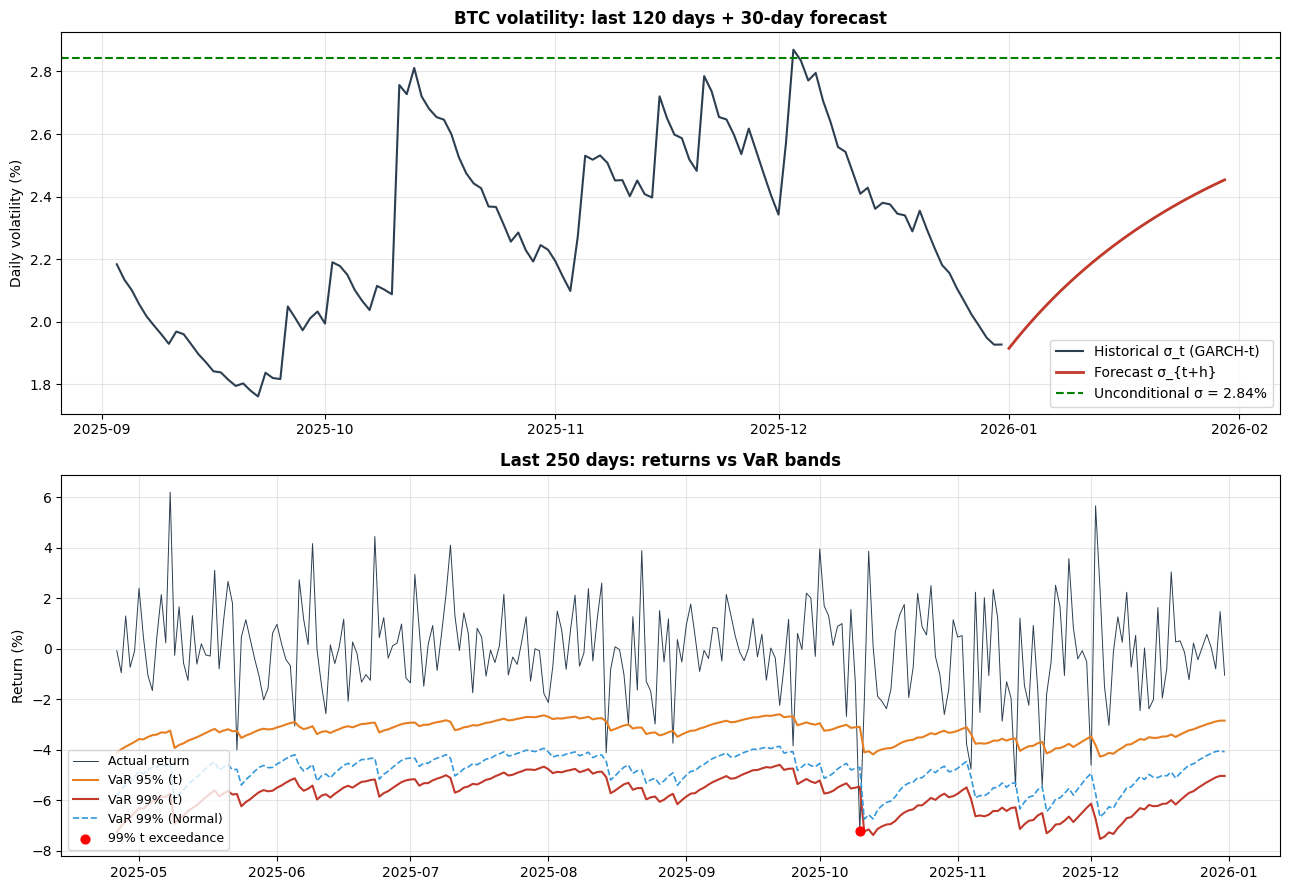

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from scipy import stats

# Ensure Series, not DataFrame
returns_recent = returns_recent.squeeze()

# Refit the winning model (GARCH-t)
model_t = arch_model(returns_recent, mean="Constant",
                     vol="GARCH", p=1, q=1, dist="t")
res_t = model_t.fit(disp="off")

# Also refit Normal for the comparison backtest
model_n = arch_model(returns_recent, mean="Constant",
                     vol="GARCH", p=1, q=1, dist="normal")
res_n = model_n.fit(disp="off")

# ===================================================================
# (A) VOLATILITY FORECAST
# ===================================================================
horizon = 30
forecast = res_t.forecast(horizon=horizon, reindex=False)

# Conditional variance forecasts (h-step ahead)
var_forecast = forecast.variance.values[-1, :]        # shape (horizon,)
vol_forecast = np.sqrt(var_forecast)                  # daily vol in %

# Unconditional (long-run) volatility from the model
omega = res_t.params["omega"]
alpha = res_t.params["alpha[1]"]
beta  = res_t.params["beta[1]"]
uncond_var = omega / (1 - alpha - beta)
uncond_vol = np.sqrt(uncond_var)

print(f"Current conditional vol (last in-sample): {res_t.conditional_volatility.iloc[-1]:.3f}%")
print(f"Unconditional (long-run) vol:             {uncond_vol:.3f}%")
print(f"α + β = {alpha + beta:.4f}  → half-life = "
      f"{np.log(0.5)/np.log(alpha + beta):.1f} days")

# Plot the forecast cone
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Recent historical vol + forecast
hist_vol = res_t.conditional_volatility.iloc[-120:]
forecast_dates = pd.date_range(hist_vol.index[-1] + pd.Timedelta(days=1),
                               periods=horizon, freq="D")

axes[0].plot(hist_vol.index, hist_vol.values,
             label="Historical σ_t (GARCH-t)", color="#2C3E50")
axes[0].plot(forecast_dates, vol_forecast,
             label="Forecast σ_{t+h}", color="#C0392B", linewidth=2)
axes[0].axhline(uncond_vol, color="green", linestyle="--",
                label=f"Unconditional σ = {uncond_vol:.2f}%")
axes[0].set_title("BTC volatility: last 120 days + 30-day forecast",
                  fontweight="bold")
axes[0].set_ylabel("Daily volatility (%)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ===================================================================
# (B) VALUE-AT-RISK — in-sample computation
# ===================================================================
mu_t = res_t.params["mu"]
sigma_t = res_t.conditional_volatility

# t-based VaR (our model) — use quantile of standardized t
nu_hat = res_t.params["nu"]
# arch uses *standardized* Student-t (unit variance) → use scipy with loc=0, scale=1
q_t_05 = stats.t.ppf(0.05, df=nu_hat) * np.sqrt((nu_hat - 2) / nu_hat)
q_t_01 = stats.t.ppf(0.01, df=nu_hat) * np.sqrt((nu_hat - 2) / nu_hat)
VaR95_t = mu_t + sigma_t * q_t_05
VaR99_t = mu_t + sigma_t * q_t_01

# Normal-based VaR (the naive comparison)
q_n_05 = stats.norm.ppf(0.05)   # -1.645
q_n_01 = stats.norm.ppf(0.01)   # -2.326
sigma_t_normal = res_n.conditional_volatility
mu_n = res_n.params["mu"]
VaR95_n = mu_n + sigma_t_normal * q_n_05
VaR99_n = mu_n + sigma_t_normal * q_n_01

# ===================================================================
# (C) BACKTEST: count exceedances
# ===================================================================
actual = returns_recent

# Align indices (first obs may differ due to conditional vol initialization)
common = actual.index.intersection(VaR95_t.index)
actual_a = actual.loc[common]
VaR95_t_a, VaR99_t_a = VaR95_t.loc[common], VaR99_t.loc[common]
VaR95_n_a, VaR99_n_a = VaR95_n.loc[common], VaR99_n.loc[common]

n = len(actual_a)
exc_95_t = (actual_a.squeeze() < VaR95_t_a).sum()
exc_99_t = (actual_a.squeeze() < VaR99_t_a).sum()
exc_95_n = (actual_a.squeeze() < VaR95_n_a).sum()
exc_99_n = (actual_a.squeeze() < VaR99_n_a).sum()

print("\n" + "="*68)
print(f"  VaR BACKTEST (in-sample, n = {n})")
print("="*68)
print(f"{'Model':<18}{'Level':<10}{'Expected':<12}{'Observed':<12}{'Rate':<10}")
print("-"*68)
print(f"{'GARCH-t':<18}{'95%':<10}{int(0.05*n):<12}{exc_95_t:<12}{exc_95_t/n:.3%}")
print(f"{'GARCH-t':<18}{'99%':<10}{int(0.01*n):<12}{exc_99_t:<12}{exc_99_t/n:.3%}")
print(f"{'GARCH-Normal':<18}{'95%':<10}{int(0.05*n):<12}{exc_95_n:<12}{exc_95_n/n:.3%}")
print(f"{'GARCH-Normal':<18}{'99%':<10}{int(0.01*n):<12}{exc_99_n:<12}{exc_99_n/n:.3%}")

# Kupiec unconditional coverage test
def kupiec_test(exceedances, n, alpha):
    """Likelihood-ratio test that observed exceedance rate = alpha."""
    x = exceedances
    if x == 0 or x == n:
        return np.nan, np.nan
    pi_hat = x / n
    ll_null = x * np.log(alpha) + (n - x) * np.log(1 - alpha)
    ll_alt  = x * np.log(pi_hat) + (n - x) * np.log(1 - pi_hat)
    LR = -2 * (ll_null - ll_alt)
    p = 1 - stats.chi2.cdf(LR, df=1)
    return LR, p

print("\n  KUPIEC TEST (H0: exceedance rate = target)")
print("-"*68)
for label, exc, alpha in [
    ("GARCH-t  95%", exc_95_t, 0.05),
    ("GARCH-t  99%", exc_99_t, 0.01),
    ("GARCH-N  95%", exc_95_n, 0.05),
    ("GARCH-N  99%", exc_99_n, 0.01),
]:
    LR, p = kupiec_test(exc, n, alpha)
    verdict = "✓ pass" if p > 0.05 else "✗ FAIL"
    print(f"{label:<18} LR = {LR:6.2f}   p = {p:.4f}   {verdict}")

# ===================================================================
# (D) VaR plot (last ~250 days for readability)
# ===================================================================
tail = 250
axes[1].plot(actual_a.index[-tail:], actual_a.values[-tail:],
             linewidth=0.7, color="#2C3E50", label="Actual return")
axes[1].plot(VaR95_t_a.index[-tail:], VaR95_t_a.values[-tail:],
             color="#E67E22", linewidth=1.5, label="VaR 95% (t)")
axes[1].plot(VaR99_t_a.index[-tail:], VaR99_t_a.values[-tail:],
             color="#C0392B", linewidth=1.5, label="VaR 99% (t)")
axes[1].plot(VaR99_n_a.index[-tail:], VaR99_n_a.values[-tail:],
             color="#3498DB", linestyle="--", linewidth=1.2,
             label="VaR 99% (Normal)")

# Mark exceedances
exc_mask = actual_a.squeeze().iloc[-tail:] < VaR99_t_a.iloc[-tail:]
axes[1].scatter(actual_a.index[-tail:][exc_mask],
                actual_a.squeeze().values[-tail:][exc_mask],
                color="red", s=40, zorder=5, label="99% t exceedance")

axes[1].set_title(f"Last {tail} days: returns vs VaR bands",
                  fontweight="bold")
axes[1].set_ylabel("Return (%)")
axes[1].legend(loc="lower left", fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()